In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [7]:
df=pd.read_csv('/kaggle/input/datasets/hosan707/job-salary-prediction-dataset/job_salary_prediction_dataset.csv')

In [8]:
data=df.copy()

# Checking the First 5 rows of the Data

In [9]:
data.head(5)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


# To know the Datatypes of the variables

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [11]:
data.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


# To Check if there are any Null values in the Dataset

In [12]:
data.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [13]:
print('In this dataset there are ',data.shape[0],' rows and ',data.shape[1],' no. of columns')

In this dataset there are  250000  rows and  10  no. of columns


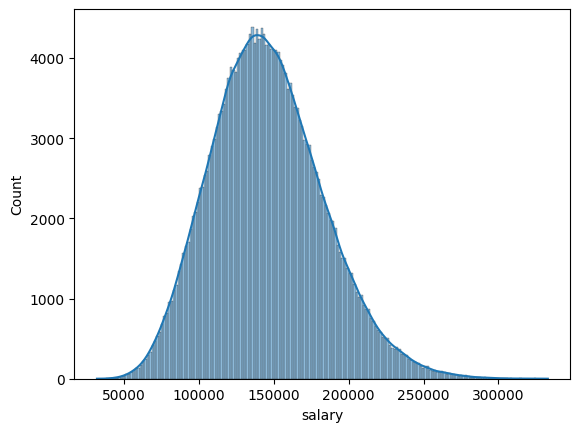

In [14]:
sns.histplot(data=data,x='salary',kde=True)
plt.show()

# Univariate Analysis

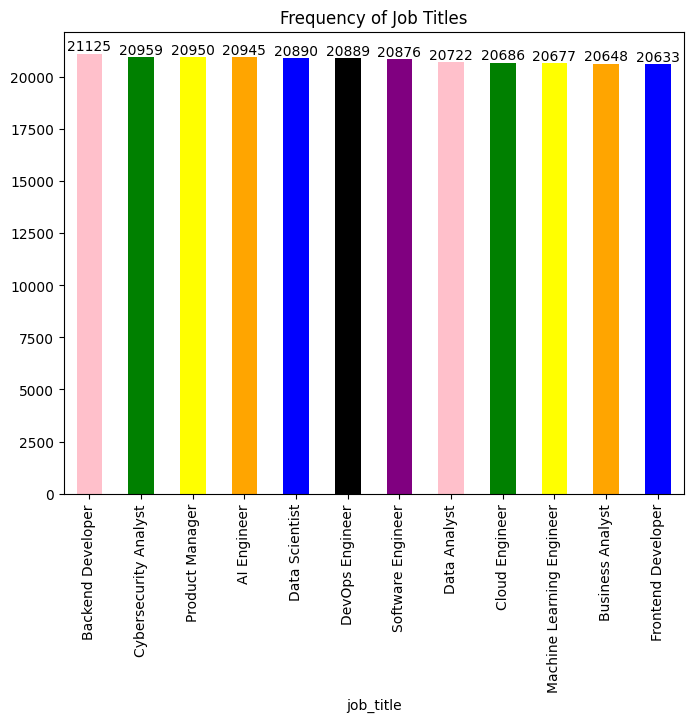

In [15]:
plt.figure(figsize=(8,6))
counts=data['job_title'].value_counts()
ax=counts.plot(kind='bar', color=['Pink','Green','Yellow','Orange','Blue','Black','Purple'])


for i,v in enumerate(counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title('Frequency of Job Titles')
plt.show()

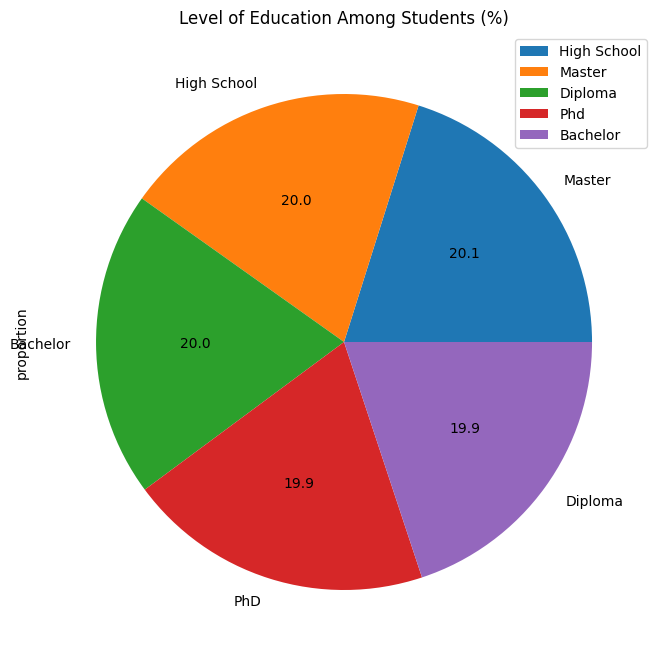

In [16]:
plt.figure(figsize=(8,9))
edu=data['education_level'].value_counts(normalize=True).mul(100).round(2)
edu.plot(kind='pie',autopct='%1.1f')
plt.title('Level of Education Among Students (%)')
plt.legend(['High School','Master','Diploma','Phd','Bachelor'])
plt.show()

In [17]:
data['company_size'].value_counts(normalize=True).mul(100).round(2)

company_size
Large         20.10
Small         20.09
Medium        20.01
Enterprise    19.95
Startup       19.84
Name: proportion, dtype: float64

# Bi-Variate

In [18]:
a=data[data['location']!='Remote']
a.shape

(224935, 10)

In [19]:
data['location']=data['location'].replace('Remote','Other')

In [20]:
print(pd.crosstab(data['location'],data['remote_work'],normalize='index').mul(100).round(2))
print('Across all countries, the proportion of respondents in hybrid, remote, and non-remote work modes remains fairly consistent at around 33%, indicating no strong variation in work mode distribution by location.')

remote_work  Hybrid     No    Yes
location                         
Australia     32.87  33.56  33.57
Canada        33.24  33.65  33.11
Germany       33.45  33.68  32.87
India         33.30  33.62  33.07
Netherlands   33.61  33.04  33.36
Other         33.74  32.85  33.41
Singapore     33.27  33.39  33.33
Sweden        33.61  33.35  33.05
UK            33.75  33.67  32.58
USA           33.07  33.68  33.26
Across all countries, the proportion of respondents in hybrid, remote, and non-remote work modes remains fairly consistent at around 33%, indicating no strong variation in work mode distribution by location.


In [21]:
print(pd.crosstab(data['job_title'],data['education_level'],normalize='index').mul(100).round(2))

print('Among Backend Developers, 21% have High School education')
print('Among Cloud Engineer, 20% have Bacehlor education')
print('Among Data Scientist, 20% have Diploma education')
print('Among Business Analyst, 21% have  Master education')
print('Among Frontend Developer, 20% have Phd education')

education_level            Bachelor  Diploma  High School  Master    PhD
job_title                                                               
AI Engineer                   20.11    19.95        20.11   20.01  19.82
Backend Developer             19.78    19.88        20.57   20.51  19.25
Business Analyst              19.75    19.69        20.03   20.49  20.05
Cloud Engineer                20.29    19.92        20.54   19.67  19.59
Cybersecurity Analyst         19.95    20.05        19.76   20.42  19.82
Data Analyst                  20.30    19.91        19.73   20.08  19.98
Data Scientist                19.84    20.33        19.79   20.04  20.00
DevOps Engineer               19.33    19.95        20.11   20.34  20.27
Frontend Developer            19.89    19.93        19.93   19.90  20.35
Machine Learning Engineer     20.18    19.88        20.07   19.89  19.99
Product Manager               20.11    19.87        19.75   19.93  20.33
Software Engineer             20.22    19.57       

In [22]:
pd.crosstab(data['company_size'],data['industry'],normalize='index').mul(100).round(2)

industry,Consulting,Education,Finance,Government,Healthcare,Manufacturing,Media,Retail,Technology,Telecom
company_size,,,,,,,,,,
Enterprise,10.11,9.89,10.10,9.96,9.91,9.95,10.07,9.88,9.97,10.16
Large,10.14,9.92,10.14,9.88,9.96,10.04,10.10,9.95,10.08,9.80
Medium,10.13,10.18,10.19,9.84,9.94,9.83,10.08,9.95,9.87,10.00
Small,10.05,9.93,10.20,10.08,10.03,10.19,9.98,9.80,9.88,9.85
Startup,10.09,9.86,10.15,10.05,9.95,10.03,9.84,10.10,10.01,9.91


In [23]:
data['skills_count'].describe()

count    250000.000000
mean          9.997812
std           5.479288
min           1.000000
25%           5.000000
50%          10.000000
75%          15.000000
max          19.000000
Name: skills_count, dtype: float64

# Feature Engineering

In [24]:
data['Skill_Count_Label']=pd.cut(data['skills_count'],bins=[1,5,10,15,20], labels=['Below Average (0-5)',' Low Skill (6-10)','Medium Skill (11-15)','High Skill (16 to 20)'])
data['Skill_Count_Label'].value_counts()

Skill_Count_Label
 Low Skill (6-10)        65950
Medium Skill (11-15)     65509
High Skill (16 to 20)    52715
Below Average (0-5)      52576
Name: count, dtype: int64

In [25]:
print(pd.crosstab(data['Skill_Count_Label'],data['company_size'],normalize='index').mul(100).round(2))
print('Observation: There is no strong relationship between skill level and company size.')


company_size           Enterprise  Large  Medium  Small  Startup
Skill_Count_Label                                               
Below Average (0-5)         19.86  20.21   19.90  20.28    19.75
 Low Skill (6-10)           20.09  19.89   20.09  20.12    19.81
Medium Skill (11-15)        19.96  20.12   19.90  20.14    19.87
High Skill (16 to 20)       19.88  20.13   20.15  19.87    19.98
Observation: There is no strong relationship between skill level and company size.


In [26]:
data['experience_years_Label']=pd.cut(data['experience_years'],bins=[0,1,5,10,15,20], labels=['Fresher (0 exp)',' 1 to 5 yrs exp.','6 to 10 yrs exp.','11 to 15 yrs exp.','Above 15 yrs exp.'])
data['experience_years_Label'].value_counts(sort=True)

experience_years_Label
11 to 15 yrs exp.    59608
Above 15 yrs exp.    59578
6 to 10 yrs exp.     59296
 1 to 5 yrs exp.     47703
Fresher (0 exp)      12011
Name: count, dtype: int64

In [27]:
pd.crosstab(data['experience_years_Label'], data['industry'], normalize='index').mul(100).round(2)

industry,Consulting,Education,Finance,Government,Healthcare,Manufacturing,Media,Retail,Technology,Telecom
experience_years_Label,,,,,,,,,,
Fresher (0 exp),9.95,9.70,10.64,10.27,9.86,9.67,10.23,9.93,10.00,9.76
1 to 5 yrs exp.,10.33,9.90,10.23,9.91,10.01,10.02,9.97,9.84,9.84,9.95
6 to 10 yrs exp.,10.13,9.94,10.33,9.89,9.95,9.81,9.99,10.08,10.01,9.87
11 to 15 yrs exp.,10.01,10.04,10.07,10.00,9.88,10.06,9.96,9.89,9.87,10.22
Above 15 yrs exp.,10.11,9.92,10.03,9.89,10.00,10.14,10.01,10.03,10.10,9.78


In [28]:
print(
    "Observation: It clearly showcases that freshers predominantly prefer Government jobs (10.27%).\n"
    "Candidates with 1–5 years of experience tend to opt for Consulting (10.33%), "
    "those with 6–10 years prefer Finance (10.33%), "
    "11–15 years of experience lean towards the Telecom industry (10.22%), "
    "and professionals with more than 15 years of experience prefer the Manufacturing industry (10.14%)."
)

Observation: It clearly showcases that freshers predominantly prefer Government jobs (10.27%).
Candidates with 1–5 years of experience tend to opt for Consulting (10.33%), those with 6–10 years prefer Finance (10.33%), 11–15 years of experience lean towards the Telecom industry (10.22%), and professionals with more than 15 years of experience prefer the Manufacturing industry (10.14%).


In [29]:
print(pd.crosstab(data['education_level'], data['company_size'], normalize='index').mul(100).round(2))
print(
"Observation: The relationship between education level and company size appears to be very weak, "
"as the distribution across company sizes remains nearly uniform for all education categories. "
"This suggests that education level has minimal influence on company size preference."
)

company_size     Enterprise  Large  Medium  Small  Startup
education_level                                           
Bachelor              19.88  20.55   19.86  19.88    19.83
Diploma               19.98  19.90   20.20  20.02    19.90
High School           19.63  20.22   20.02  20.27    19.86
Master                20.22  19.80   20.12  20.16    19.70
PhD                   20.04  20.04   19.85  20.15    19.93
Observation: The relationship between education level and company size appears to be very weak, as the distribution across company sizes remains nearly uniform for all education categories. This suggests that education level has minimal influence on company size preference.


In [30]:
pd.crosstab(data['education_level'], data['location'], normalize='index').mul(100).round(2)

location,Australia,Canada,Germany,India,Netherlands,Other,Singapore,Sweden,UK,USA
education_level,,,,,,,,,,
Bachelor,9.98,10.06,9.75,10.23,9.83,9.99,10.15,10.14,10.00,9.87
Diploma,10.04,10.04,9.90,9.89,9.89,9.99,10.15,10.15,10.07,9.89
High School,10.32,9.89,10.09,9.85,10.07,9.97,9.86,10.01,9.97,9.96
Master,10.13,10.25,9.85,9.84,9.95,10.12,9.92,9.92,9.88,10.14
PhD,10.04,10.09,9.94,9.98,9.98,10.06,9.99,9.98,9.94,9.99


In [31]:
pd.crosstab(data['job_title'], data['experience_years_Label'], normalize='columns').mul(100).round(2)

experience_years_Label,Fresher (0 exp),1 to 5 yrs exp.,6 to 10 yrs exp.,11 to 15 yrs exp.,Above 15 yrs exp.
job_title,,,,,
AI Engineer,8.35,8.45,8.36,8.39,8.36
Backend Developer,8.03,8.45,8.55,8.37,8.44
Business Analyst,8.29,8.19,8.31,8.28,8.32
Cloud Engineer,8.35,8.24,8.24,8.35,8.28
Cybersecurity Analyst,8.60,8.33,8.40,8.38,8.36
Data Analyst,8.47,8.27,8.30,8.31,8.26
Data Scientist,8.08,8.12,8.38,8.44,8.52
DevOps Engineer,8.23,8.31,8.41,8.40,8.30
Frontend Developer,8.94,8.46,8.30,8.03,8.09


In [32]:
print(
"Observation: Across all experience levels, job roles are distributed fairly uniformly, "
"with only marginal variations. For freshers, roles like Frontend Developer and Machine Learning Engineer "
"show slightly higher representation; however, the differences are minimal and do not indicate a strong preference."
)

Observation: Across all experience levels, job roles are distributed fairly uniformly, with only marginal variations. For freshers, roles like Frontend Developer and Machine Learning Engineer show slightly higher representation; however, the differences are minimal and do not indicate a strong preference.


The skill distribution does not exhibit strong polarization; instead, it reflects a relatively even spread, with a mild concentration in the low-to-medium range.”


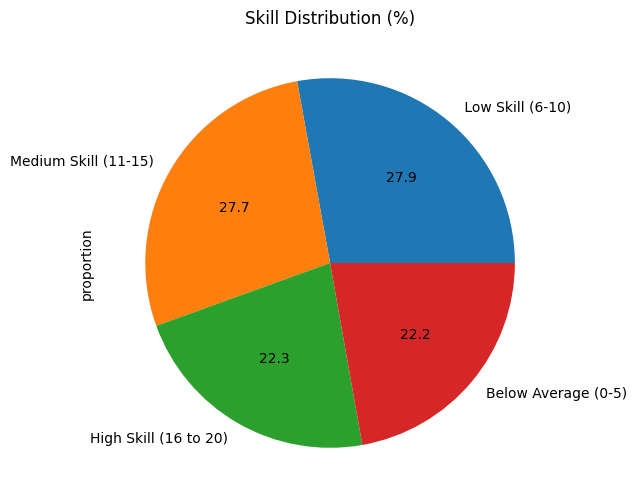

In [33]:
plt.figure(figsize=(10,6))
data['Skill_Count_Label'].value_counts(normalize=True).sort_values(ascending=False).plot(kind='pie', autopct='%1.1f')
plt.title('Skill Distribution (%)')
print('The skill distribution does not exhibit strong polarization; instead, it reflects a relatively even spread, with a mild concentration in the low-to-medium range.”')
plt.show()

# Important Observations to Observe

# Question: How many % of people working remotely in India?


In [34]:

India_remote_work=data[data['location']=='India']['remote_work']
print(India_remote_work.value_counts(normalize=True).mul(100).round(2))

print('Observation: The distribution of work modes (remote, hybrid, and onsite) in India is nearly uniform')

remote_work
No        33.62
Hybrid    33.30
Yes       33.07
Name: proportion, dtype: float64
Observation: The distribution of work modes (remote, hybrid, and onsite) in India is nearly uniform


# What % of company size does India holds

In [35]:
India_industry=data[data['location']=='India']['company_size']
India_industry.value_counts(normalize=True).mul(100).round(2)

company_size
Enterprise    20.09
Startup       20.08
Medium        20.02
Large         19.98
Small         19.82
Name: proportion, dtype: float64

# How much % of people work in Healthcare in India

In [36]:
India_Health_company=data[data['location']=='India']['industry']
op=India_Health_company.value_counts(normalize=True).mul(100).round(2)['Healthcare']
print(f'About {op} % of people how are in India works under Healthcare')

About 9.8 % of people how are in India works under Healthcare


In [37]:
data['certifications'].describe()

count    250000.000000
mean          2.491928
std           1.706475
min           0.000000
25%           1.000000
50%           2.000000
75%           4.000000
max           5.000000
Name: certifications, dtype: float64

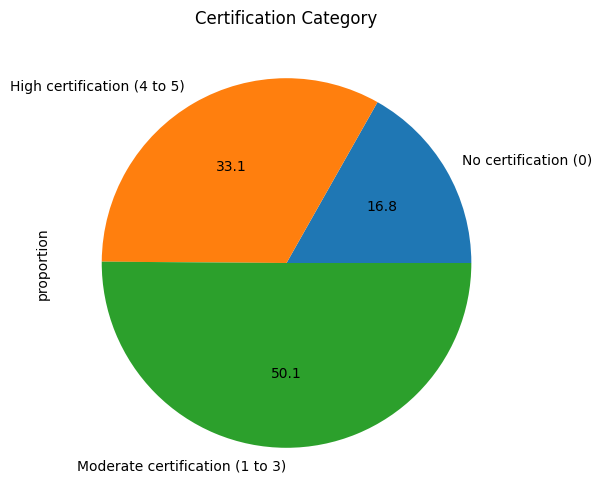

In [38]:
plt.figure(figsize=(10,6))
data['certifications_labels']=pd.cut(data['certifications'],bins=[-1,0,3,5], labels=['No certification (0) ','Moderate certification (1 to 3)','High certification (4 to 5)'])
data['certifications_labels'].value_counts(normalize=True).sort_values(ascending=True).mul(100).round(2).plot(kind='pie',autopct='%1.1f')
plt.title('Certification Category')
plt.show()


# How percentage of certification courses require at Large scale company?

In [39]:
certificate_large=data[data['company_size']=='Large']['certifications_labels']
print(certificate_large.value_counts(normalize=True).mul(100).round(2))

print('Observation: Large companies tend to have a higher concentration of employees with at least some level of certification, with over 80% possessing one or more certifications. This suggests that certifications may be valued in large organizations, although no causal relationship can be inferred.')

certifications_labels
Moderate certification (1 to 3)    50.33
High certification (4 to 5)        32.95
No certification (0)               16.72
Name: proportion, dtype: float64
Observation: Large companies tend to have a higher concentration of employees with at least some level of certification, with over 80% possessing one or more certifications. This suggests that certifications may be valued in large organizations, although no causal relationship can be inferred.


# How does certification level vary across countries?

In [40]:
pd.crosstab(data['location'],data['certifications_labels'],normalize='index').mul(100).round(2)


certifications_labels,No certification (0),Moderate certification (1 to 3),High certification (4 to 5)
location,,,
Australia,17.10,50.19,32.71
Canada,16.79,50.08,33.13
Germany,16.67,50.03,33.30
India,17.00,49.98,33.02
Netherlands,16.89,49.90,33.22
Other,16.66,50.59,32.75
Singapore,17.08,49.75,33.17
Sweden,16.75,49.70,33.55
UK,16.95,50.48,32.57


In [41]:
print(
"Observation: The distribution of certification levels across countries is highly uniform, "
"with minimal variation observed. This indicates that there is no significant relationship "
"between geographic location and certification levels in the dataset."
)

Observation: The distribution of certification levels across countries is highly uniform, with minimal variation observed. This indicates that there is no significant relationship between geographic location and certification levels in the dataset.


# Does certification level vary across education levels?

In [42]:
pd.crosstab(data['education_level'],data['certifications_labels'],normalize='index').mul(100).round(2)

certifications_labels,No certification (0),Moderate certification (1 to 3),High certification (4 to 5)
education_level,,,
Bachelor,16.84,50.15,33.02
Diploma,16.86,50.18,32.96
High School,16.93,49.74,33.33
Master,16.57,50.31,33.12
PhD,16.83,50.21,32.96


In [43]:
print("Observation: Contrary to expectations, higher education levels do not correspond to higher certification attainment, as the distribution remains nearly identical across all groups")

Observation: Contrary to expectations, higher education levels do not correspond to higher certification attainment, as the distribution remains nearly identical across all groups


# Is higher experience and certification associated with higher salary levels?

In [44]:
data['salary'].describe()

count    250000.000000
mean     145718.080524
std       37407.952729
min       31867.000000
25%      119358.000000
50%      143453.000000
75%      169492.000000
max      333046.000000
Name: salary, dtype: float64

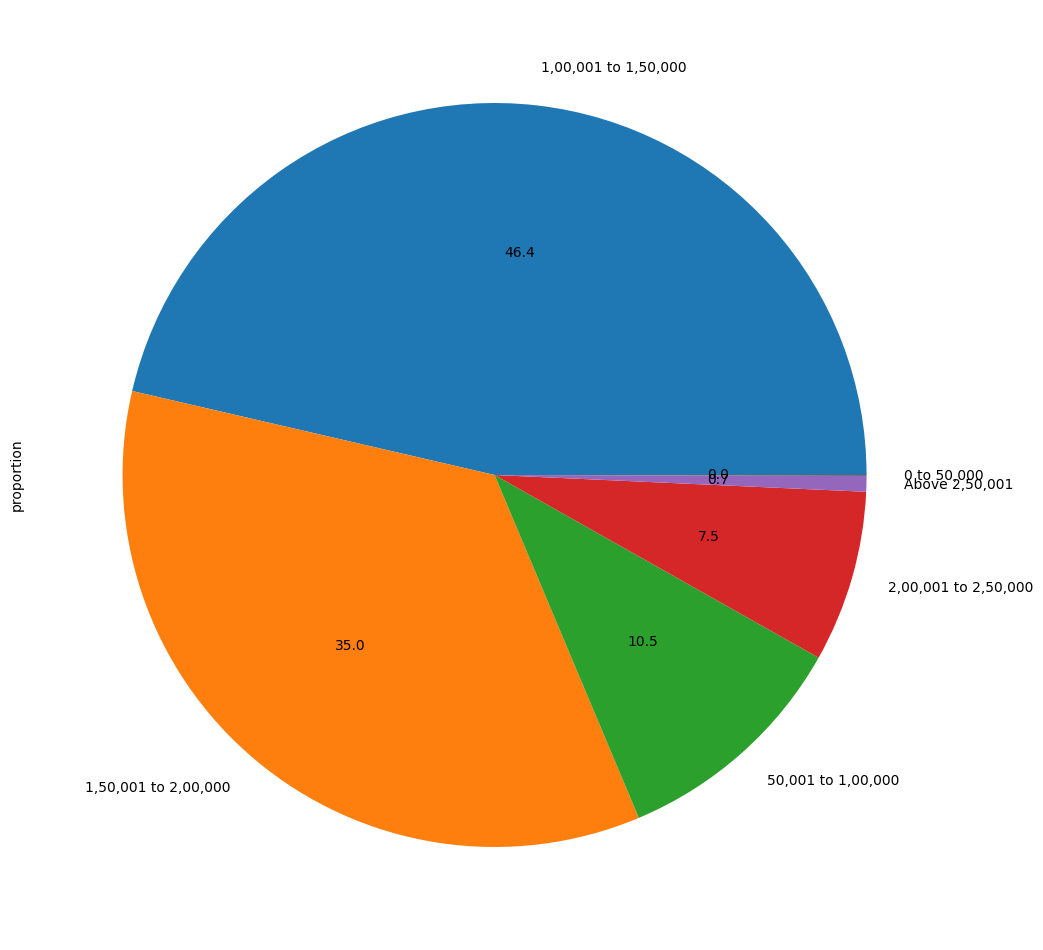

In [45]:
plt.figure(figsize=(12,20))
data['salary_range']=pd.cut(data['salary'], bins=[0,50000,100000,150000,200000,250000,400000],labels=['0 to 50,000','50,001 to 1,00,000','1,00,001 to 1,50,000','1,50,001 to 2,00,000','2,00,001 to 2,50,000','Above 2,50,001'])
data['salary_range'].value_counts(normalize=True).sort_values(ascending=False).mul(100).round(2).plot(kind='pie',autopct='%0.1f')
plt.show()

In [46]:
data['salary_range'].value_counts(normalize=True).sort_values(ascending=False).mul(100).round(2)

salary_range
1,00,001 to 1,50,000    46.37
1,50,001 to 2,00,000    34.96
50,001 to 1,00,000      10.49
2,00,001 to 2,50,000     7.45
Above 2,50,001           0.68
0 to 50,000              0.04
Name: proportion, dtype: float64

In [47]:
pd.crosstab([data['experience_years_Label'],data['certifications_labels']],data['salary_range'], normalize='index').mul(100).round(2)

salary_range                                            0 to 50,000  \
experience_years_Label certifications_labels                          
Fresher (0 exp)        No certification (0)                    0.24   
                       Moderate certification (1 to 3)         0.21   
                       High certification (4 to 5)             0.10   
 1 to 5 yrs exp.       No certification (0)                    0.14   
                       Moderate certification (1 to 3)         0.10   
                       High certification (4 to 5)             0.09   
6 to 10 yrs exp.       No certification (0)                    0.00   
                       Moderate certification (1 to 3)         0.00   
                       High certification (4 to 5)             0.00   
11 to 15 yrs exp.      No certification (0)                    0.00   
                       Moderate certification (1 to 3)         0.00   
                       High certification (4 to 5)             0.00   
Above 15 yrs exp.      No certification (0)                    0.00   
                       Moderate certification (1 to 3)         0.00   
                       High certification (4 to 5)             0.00   

salary_range                                            50,001 to 1,00,000  \
experience_years_Label certifications_labels                                 
Fresher (0 exp)        No certification (0)                          29.05   
                       Moderate certification (1 to 3)               25.60   
                       High certification (4 to 5)                   21.20   
 1 to 5 yrs exp.       No certification (0)                          21.24   
                       Moderate certification (1 to 3)               19.06   
                       High certification (4 to 5)                   15.84   
6 to 10 yrs exp.       No certification (0)                          12.81   
                       Moderate certification (1 to 3)               10.91   
                       High certification (4 to 5)                    8.84   
11 to 15 yrs exp.      No certification (0)                           6.17   
                       Moderate certification (1 to 3)                5.93   
                       High certification (4 to 5)                    4.80   
Above 15 yrs exp.      No certification (0)                           3.77   
                       Moderate certification (1 to 3)                2.92   
                       High certification (4 to 5)                    2.49   

salary_range                                            1,00,001 to 1,50,000  \
experience_years_Label certifications_labels                                   
Fresher (0 exp)        No certification (0)                            56.11   
                       Moderate certification (1 to 3)                 57.89   
                       High certification (4 to 5)                     59.08   
 1 to 5 yrs exp.       No certification (0)                            59.50   
                       Moderate certification (1 to 3)                 58.68   
                       High certification (4 to 5)                     57.96   
6 to 10 yrs exp.       No certification (0)                            56.23   
                       Moderate certification (1 to 3)                 53.27   
                       High certification (4 to 5)                     51.26   
11 to 15 yrs exp.      No certification (0)                            45.93   
                       Moderate certification (1 to 3)                 42.64   
                       High certification (4 to 5)                     39.37   
Above 15 yrs exp.      No certification (0)                            33.28   
                       Moderate certification (1 to 3)                 30.19   
                       High certification (4 to 5)                     26.51   

salary_range                                            1,50,001 to 2,00,000  \
experience_years_Label c

In [48]:
print('Observation: Experience determines your position, but certifications accelerate your growth within that position.')

Observation: Experience determines your position, but certifications accelerate your growth within that position.


# How does Salary vary with skill level?

In [49]:
pd.crosstab(data['Skill_Count_Label'],data['salary_range'],normalize='index').mul(100).round(2)

salary_range,"0 to 50,000","50,001 to 1,00,000","1,00,001 to 1,50,000","1,50,001 to 2,00,000","2,00,001 to 2,50,000","Above 2,50,001"
Skill_Count_Label,,,,,,
Below Average (0-5),0.07,13.31,49.31,31.28,5.62,0.41
Low Skill (6-10),0.06,11.14,48.02,33.45,6.74,0.58
Medium Skill (11-15),0.03,9.13,44.52,37.24,8.29,0.79
High Skill (16 to 20),0.01,7.61,42.46,39.11,9.76,1.06


In [50]:
print('Higher skill levels are consistently associated with upward movement in salary distribution, with a clear transition from mid-range to higher salary brackets as skill increases.')

Higher skill levels are consistently associated with upward movement in salary distribution, with a clear transition from mid-range to higher salary brackets as skill increases.


# Is there variation in salary distribution across different job roles?

In [51]:
pd.crosstab(data['job_title'],data['salary_range'],normalize='index').mul(100).round(2)

salary_range,"0 to 50,000","50,001 to 1,00,000","1,00,001 to 1,50,000","1,50,001 to 2,00,000","2,00,001 to 2,50,000","Above 2,50,001"
job_title,,,,,,
AI Engineer,0.00,2.11,24.97,49.86,19.96,3.09
Backend Developer,0.01,11.08,53.88,30.65,4.21,0.18
Business Analyst,0.27,24.40,56.61,17.38,1.31,0.03
Cloud Engineer,0.00,6.13,43.86,40.69,8.65,0.66
Cybersecurity Analyst,0.00,7.14,46.67,38.63,7.03,0.53
Data Analyst,0.22,27.04,56.23,15.48,1.03,0.00
Data Scientist,0.00,7.62,48.04,37.25,6.72,0.38
DevOps Engineer,0.00,6.53,45.75,39.60,7.67,0.45
Frontend Developer,0.02,15.89,56.08,25.28,2.64,0.09


<table> 
    <tr>
        <th> Job Title</th>
        <th>Jump from 50k to 1.5l </th>
        <th>Jump from 1.5l to 2l </th>
    </tr>
    <tr>
        <td>AI Engineering</td>
        <td>22.86</td>
        <td>24.89</td>
    </tr>
    <tr>
        <td>Backend Developer</td>
        <td>42.8</td>
        <td>-23.23</td>
    </tr>
    <tr>
        <td>Business Analyst</td>
        <td>32.21</td>
        <td>-39.23</td>
    </tr>
    <tr>
        <td>Cloud Engineer</td>
        <td>37.73</td>
        <td>-3.17</td>
    </tr>
    <tr>
        <td>Cybersecurity Analyst</td>
        <td>39.53</td>
        <td>-8.04</td>
    </tr>
    <tr>
        <td>Data Analyst</td>
        <td>29.19</td>
        <td>-40.75</td>
    </tr>
    <tr>
        <td>Data Scientist</td>
        <td>40.42</td>
        <td>-10.79</td>
    </tr>
    <tr>
        <td>Devops Engineer</td>
        <td>39.22</td>
        <td>-6.15</td>
    </tr>
    <tr>
        <td>Frontend Developer</td>
        <td>40.19</td>
        <td>-30.8</td>
    </tr>
    <tr>
        <td>Machine Learning Engineer</td>
        <td>30.1</td>
        <td>12.9</td>
    </tr>
    <tr>
        <td>Product Manager</td>
        <td>34.53</td>
        <td>5.51</td>
    </tr>
    <tr>
        <td>Software Engineer</td>
        <td>41.66</td>
        <td>-18.57</td>
    </tr>
</table>

In [53]:
print('Observation: Different job roles exhibit distinct salary positioning, with specialized roles skewed toward higher compensation and generalist roles concentrated in mid-level salary ranges')

Observation: Different job roles exhibit distinct salary positioning, with specialized roles skewed toward higher compensation and generalist roles concentrated in mid-level salary ranges


# How does salary distribution vary across industries and company sizes?

In [54]:
pd.crosstab([data['industry'],data['company_size']],data['salary_range'],normalize='index').mul(100).round(2)

salary_range                0 to 50,000  50,001 to 1,00,000  \
industry      company_size                                    
Consulting    Enterprise           0.00                3.85   
              Large                0.02                5.65   
              Medium               0.06               11.03   
              Small                0.04               13.79   
              Startup              0.16               18.59   
Education     Enterprise           0.00                3.32   
              Large                0.02                6.14   
              Medium               0.04                9.86   
              Small                0.06               13.45   
              Startup              0.04               18.28   
Finance       Enterprise           0.00                3.16   
              Large                0.02                6.20   
              Medium               0.00               10.54   
              Small                0.10               15.06   
              Startup              0.14               18.28   
Government    Enterprise           0.00                3.36   
              Large                0.02                6.37   
              Medium               0.02               11.07   
              Small                0.04               14.07   
              Startup              0.10               17.77   
Healthcare    Enterprise           0.00                3.20   
              Large                0.00                6.20   
              Medium               0.00               10.33   
              Small                0.12               14.27   
              Startup              0.08               18.55   
Manufacturing Enterprise           0.00                3.06   
              Large                0.04                5.87   
              Medium               0.00               10.83   
              Small                0.02               15.00   
              Startup              0.08               18.06   
Media         Enterprise           0.00                3.29   
              Large                0.00                5.85   
              Medium               0.10               10.53   
              Small                0.06               14.08   
              Startup              0.06               17.88   
Retail        Enterprise           0.00                3.37   
              Large                0.00                6.70   
              Medium               0.06               10.77   
              Small                0.10               13.83   
              Startup              0.16               18.87   
Technology    Enterprise           0.00                3.46   
              Large                0.00                6.02   
              Medium               0.04               10.58   
              Small                0.10               13.54   
              Startup              0.18               18.85   
Telecom       Enterprise           0.00                3.34   
              Large                0.02                5.91   
              Medium               0.02               10.18   
              Small                0.04               13.84   
              Startup              0.04               18.91   

salary_range                1,00,001 to 1,50,000  1,50,001 to 2,00,000  \
industry      company_size                                               
Consulting    Enterprise                   27.93                 46.92   
              Large                        38.28                 44.56   
              Medium                       49.01                 35.81   
              Small                        56.16                 27.95   
              Startup                      60.95                 19.31   
Education     Enterprise                   28.38                 45.85   
              Large                        37.79                 44.79   
              Medium                       50.38         

In [55]:
print('Observation: While industry differences are minimal, company size emerges as the primary factor influencing salary distribution.')

Observation: While industry differences are minimal, company size emerges as the primary factor influencing salary distribution.


# Model Building

In [56]:
X=data.drop(columns=['salary','salary_range'])
Y=data['salary']

num_cols=X.select_dtypes(include=['int','float64']).columns
cat_cols=X.select_dtypes(include=['object']).columns

## Pre-Process

In [57]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression

preprocessor=ColumnTransformer([
    ('num',StandardScaler(),num_cols),
    ('cat',OneHotEncoder(),cat_cols)
])

In [58]:
from sklearn.pipeline import Pipeline

model=Pipeline([
    ('preprocessor',preprocessor),
    ('regression',LinearRegression())
])

model.fit(X,Y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['experience_years', 'skills_count', 'certifications'], dtype='object')),
                                                 ('cat', OneHotEncoder(),
                                                  Index(['job_title', 'education_level', 'industry', 'company_size', 'location',
       'remote_work'],
      dtype='object'))])),
                ('regression', LinearRegression())])

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test,Y_train,Y_test=train_test_split(X,Y,random_state=42,test_size=0.2)

model.fit(X_train,Y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['experience_years', 'skills_count', 'certifications'], dtype='object')),
                                                 ('cat', OneHotEncoder(),
                                                  Index(['job_title', 'education_level', 'industry', 'company_size', 'location',
       'remote_work'],
      dtype='object'))])),
                ('regression', LinearRegression())])

In [60]:
y_pred=model.predict(X_test)

print(y_pred)

[172850.84694068  89234.51854182  63791.55134444 ... 165227.44895727
 151849.72558748 111755.77171383]


In [61]:
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score
print('R2 score',r2_score(Y_test,y_pred))
print('Mean Absoulte Error',mean_absolute_error(Y_test,y_pred))


R2 score 0.9634690226760201
Mean Absoulte Error 5436.0969586494775


In [62]:
print('he model performs very well, explaining most of the variation in salary, and the average prediction error is relatively low at around Rs.5,400')

he model performs very well, explaining most of the variation in salary, and the average prediction error is relatively low at around Rs.5,400


# Feature Importance and Coefficient

In [63]:
import pandas as pd
import numpy as np

# Get feature names after preprocessing
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# Get coefficients
coefficients = model.named_steps['regression'].coef_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by importance (absolute value)
feature_importance['Abs'] = np.abs(feature_importance['Coefficient'])

feature_importance = feature_importance.sort_values(by='Abs', ascending=False)

print(feature_importance.head(10))

                                     Feature   Coefficient           Abs
38                       cat__location_India -48151.716307  48151.716307
44                         cat__location_USA  35674.292642  35674.292642
3                 cat__job_title_AI Engineer  28027.316349  28027.316349
8                cat__job_title_Data Analyst -25732.230031  25732.230031
30              cat__company_size_Enterprise  24042.384430  24042.384430
5            cat__job_title_Business Analyst -23515.256640  23515.256640
36                      cat__location_Canada  21644.188224  21644.188224
34                 cat__company_size_Startup -18356.920691  18356.920691
19                  cat__education_level_PhD  18276.951592  18276.951592
12  cat__job_title_Machine Learning Engineer  17367.442738  17367.442738


In [64]:
from sklearn.inspection import permutation_importance

perm=permutation_importance(
    model, X_test, Y_test,n_repeats=10, random_state=42
)

importance_df=pd.DataFrame({
    'Features':X.columns,
    'Importance':perm.importances_mean
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)

                  Features  Importance
6                 location    0.650581
1         experience_years    0.383384
5             company_size    0.331976
0                job_title    0.326749
2          education_level    0.192502
3             skills_count    0.032028
8           certifications    0.010944
7              remote_work    0.009151
10  experience_years_Label    0.000000
9        Skill_Count_Label    0.000000
11   certifications_labels    0.000000
4                 industry   -0.000002


In [65]:
print(
"Observation: Location emerges as the most influential predictor of salary, followed by experience, company size, and job role. "
"Education level has a moderate impact, while factors such as skills, certifications, and remote work contribute minimally to salary prediction."
)

Observation: Location emerges as the most influential predictor of salary, followed by experience, company size, and job role. Education level has a moderate impact, while factors such as skills, certifications, and remote work contribute minimally to salary prediction.


# Buiding Model based on Important Features


## Decision Tree

In [66]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

selected_features=['location','experience_years','company_size','job_title','education_level']
X_new=data[selected_features]
y=data['salary']


num_cols1=['experience_years']
cat_cols1=['location','company_size','job_title','education_level']

preprocessor1=ColumnTransformer([
    ('num',StandardScaler(),num_cols1),
    ('cat',OneHotEncoder(),cat_cols1)
])

X_train1,X_test1,Y_train1,Y_test1=train_test_split(X_new,y,test_size=0.20,random_state=42)

dt_model=Pipeline([
    ('preprocessor1',preprocessor1),
    ('model',DecisionTreeRegressor())
])

dt_model.fit(X_train1,Y_train1)

pred_dt_model=dt_model.predict(X_test1)

print("Decision Tree R2:", r2_score(Y_test1, pred_dt_model))
print("Decision Tree MAE:", mean_absolute_error(Y_test1, pred_dt_model))





Decision Tree R2: 0.9361155360781294
Decision Tree MAE: 7495.600411001443


# Random Forest Model

In [ ]:
random_ft_model=Pipeline([
      ('preprocessor1',preprocessor1),
    ('model',RandomForestRegressor(n_estimators=100, random_state=42))
])

random_ft_model.fit(X_train1,Y_train1)
pred_random_ft_model=random_ft_model.predict(X_test1)


print("Random Forest R2:", r2_score(Y_test1, pred_random_ft_model))
print("Random Forest MAE:", mean_absolute_error(Y_test1, pred_random_ft_model))


In [68]:
print('Linear Regression  Model R2 score is 0.96')
print('Linear Regression Model MAE is 5436')

print('Decision Tree R2: 0.93')
print('Decision Tree MAE: 7497')

print('Random Forest R2: 0.94 ')
print('Random Forest MAE: 7184')


Linear Regression  Model R2 score is 0.96
Linear Regression Model MAE is 5436
Decision Tree R2: 0.93
Decision Tree MAE: 7497
Random Forest R2: 0.94 
Random Forest MAE: 7184


# Final Observation

In [69]:
print('Linear Regression outperformed tree-based models, indicating that the relationship between features and salary is largely linear. While Random Forest improved over Decision Tree, it still did not surpass the linear model, suggesting limited non-linear interactions in the dataset.”')

Linear Regression outperformed tree-based models, indicating that the relationship between features and salary is largely linear. While Random Forest improved over Decision Tree, it still did not surpass the linear model, suggesting limited non-linear interactions in the dataset.”
